In [1]:
import pandas as pd
import numpy as np
import pickle

from scipy.sparse import load_npz

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score

In [2]:
# Load TF-IDF features
X_train_tfidf = load_npz(
    "../data/processed/X_train_tfidf.npz"
)

X_test_tfidf = load_npz(
    "../data/processed/X_test_tfidf.npz"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).values.ravel()

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).values.ravel()

print("X_train:", X_train_tfidf.shape)
print("X_test:", X_test_tfidf.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (31323, 10000)
X_test: (7831, 10000)
y_train: (31323,)
y_test: (7831,)


In [3]:
# logistic regression
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9946367002937045


In [4]:
# naive bayes
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9636061805644235


In [5]:
# random forest
X_train_rf = X_train_tfidf[:, :5000]
X_test_rf = X_test_tfidf[:, :5000]

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train
)

rf_pred = rf_model.predict(X_test_rf)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9894010981994636


In [ ]:
# neural network
# We'll use a simple MLP with one hidden layer because the full 10,000-dimensional sparse matrix can be heavy for an MLP, we'll use the first 3,000 TF-IDF features.
X_train_nn = X_train_tfidf[:, :3000].toarray()
X_test_nn = X_test_tfidf[:, :3000].toarray()

print(X_train_nn.shape)

(31323, 3000)


In [7]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=30,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

nn_model.fit(
    X_train_nn,
    y_train
)

nn_pred = nn_model.predict(X_test_nn)

nn_accuracy = accuracy_score(
    y_test,
    nn_pred
)

print("Neural Network Accuracy:", nn_accuracy)

Neural Network Accuracy: 0.9785468011748181


C:\Users\rahul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [8]:
# compare all models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Neural Network"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        rf_accuracy,
        nn_accuracy
    ]
})

results = results.sort_values(
    "Accuracy",
    ascending=False
)

results

,Model,Accuracy
0,Logistic Regression,0.994637
2,Random Forest,0.989401
3,Neural Network,0.978547
1,Naive Bayes,0.963606


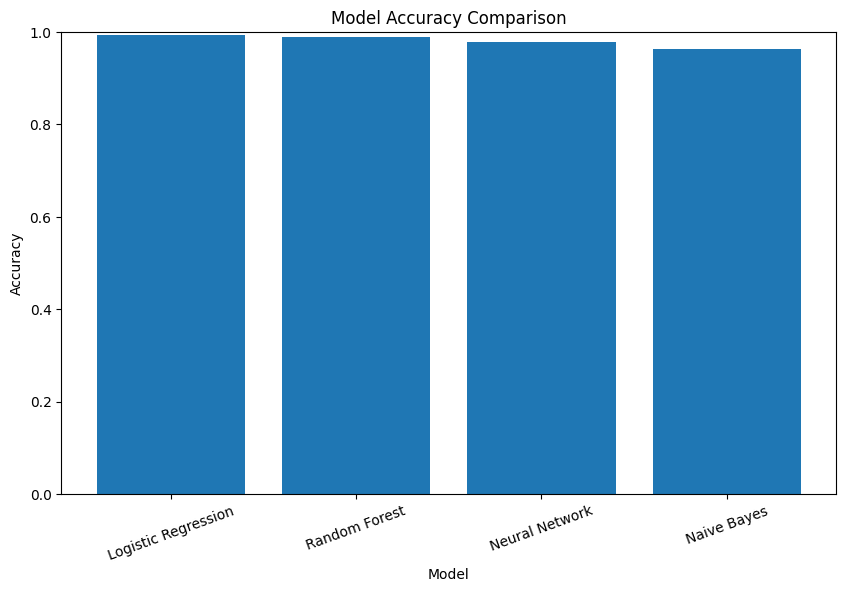

In [9]:
# visualize accuracy comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.ylim(0, 1)

plt.show()

In [10]:
# save models
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    lr_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    nb_model,
    "../models/naive_bayes.pkl"
)

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

joblib.dump(
    nn_model,
    "../models/neural_network.pkl"
)

print("All models saved successfully!")

All models saved successfully!


In [11]:
# save comparison results
os.makedirs("../results", exist_ok=True)

results.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!
